# Ridge, Lasso and Elastic Net from Scratch

Ordinary least squares picks the coefficient vector that makes the squared error as small as
possible:

$$\hat\beta = \arg\min_\beta \ \lVert y - X\beta \rVert_2^2$$

Setting the gradient to zero gives the normal equations, and their solution is

$$\hat\beta = (X^\top X)^{-1} X^\top y$$

That formula needs $X^\top X$ to be invertible, and invertible in a numerical sense, not just in
principle. When two columns of $X$ carry nearly the same information, the matrix has an eigenvalue
close to zero. Inverting it divides by that eigenvalue, so a small wobble in $y$ turns into an
enormous swing in $\hat\beta$. The ratio of the largest eigenvalue to the smallest is the
**condition number**, and it is the direct measure of how badly this happens.

The three methods below all attack the same problem by adding a penalty on the size of $\beta$ to
the loss:

- **Ridge** adds $\lambda\lVert\beta\rVert_2^2$. Solvable in closed form, shrinks every coefficient
  toward zero, and never sets one exactly to zero.
- **Lasso** adds $\lambda\lVert\beta\rVert_1$. No closed form, but it drives coefficients to exactly
  zero, so it selects features.
- **Elastic Net** adds both, taking the feature selection from L1 and the stability from L2.

The dataset is UCI Communities and Crime: 1994 US communities, 127 columns, predicting the violent
crime rate per capita. It was chosen because the predictors overlap heavily - dozens of related
measures of income, race, family structure, housing, immigration and age - so $X^\top X$ has a wide
spread of eigenvalues and $\hat\beta$ is poorly determined along the smallest of them. How much that
actually costs on this split is measured below rather than assumed.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import style
from ucimlrepo import fetch_ucirepo

style.use('ggplot')

blue = '#2a78d6'
orange = '#eb6834'
aqua = '#1baf7a'

np.random.seed(42)

## Loading the data

`fetch_ucirepo(id=183)` downloads the dataset as a features frame and a targets frame. The target
column is `ViolentCrimesPerPop`, already normalised to the range 0 to 1, so it is a continuous
regression target and needs no further scaling.

Missing values in this dataset are not stored as `NaN` - they are stored as the string `'?'`. Pandas
therefore reads any column containing one as `object` dtype, and `isna()` reports nothing missing.
The cell counts both so the difference is visible before anything is cleaned.

In [2]:
crime = fetch_ucirepo(id=183)

X_raw = crime.data.features
y_raw = crime.data.targets

print('features frame:', X_raw.shape)
print('targets frame: ', y_raw.shape, list(y_raw.columns))
print()

object_cols = list(X_raw.dtypes[X_raw.dtypes == object].index)
print('columns read as object dtype:', len(object_cols))
print('NaN values reported before converting "?":', int(X_raw.isna().sum().sum()))
print('cells holding the string "?":', int((X_raw == '?').sum().sum()))

features frame: (1994, 127)
targets frame:  (1994, 1) ['ViolentCrimesPerPop']

columns read as object dtype: 26
NaN values reported before converting "?": 0
cells holding the string "?": 39202


## Cleaning

Three things happen here.

`replace('?', np.nan)` turns the placeholder into a real missing value so the counts below are
honest.

Five columns are dropped because they identify a community rather than describe one: `state`,
`county` and `community` are numeric codes, `communityname` is a string, and `fold` is the
dataset's own cross-validation index. None of them is a predictor.

`missing_frac` is then the fraction of rows missing in each remaining column. Every column above
the 20% threshold comes from the LEMAS police survey, which was only completed by a small minority
of communities, so those columns are dropped whole rather than imputed. After that only one cell
anywhere is still missing, and `dropna` removes its row.

`to_numeric` runs after the identifier drop so that columns which were only `object` dtype because
of `'?'` become float.

In [3]:
frame = X_raw.replace('?', np.nan)

identifiers = ['state', 'county', 'community', 'communityname', 'fold']
frame = frame.drop(columns=identifiers)
frame = frame.apply(pd.to_numeric, errors='coerce')

missing_frac = frame.isna().mean()
mostly_missing = list(missing_frac[missing_frac > 0.2].index)
frame = frame.drop(columns=mostly_missing)

print('dropped %d identifier columns:' % len(identifiers), identifiers)
print()
print('dropped %d columns missing in more than 20%% of rows' % len(mostly_missing))
print('  each of them is missing for %.1f%% of rows' % (100 * missing_frac[mostly_missing[0]]))
print(' ', mostly_missing)
print()

feature_names = list(frame.columns)
target_name = 'ViolentCrimesPerPop'

full = pd.concat([frame, y_raw], axis=1)
rows_before = len(full)
full = full.dropna()
print('dropped %d row(s) still holding a missing value' % (rows_before - len(full)))
print()

X_all = full[feature_names].values.astype(float)
y_all = full[target_name].values.astype(float)

print('127 columns -> %d features' % len(feature_names))
print('%d rows -> %d rows' % (rows_before, len(full)))
print('X:', X_all.shape, ' y:', y_all.shape)
print('target range: %.3f to %.3f' % (y_all.min(), y_all.max()))

dropped 5 identifier columns: ['state', 'county', 'community', 'communityname', 'fold']

dropped 22 columns missing in more than 20% of rows
  each of them is missing for 84.0% of rows
  ['LemasSwornFT', 'LemasSwFTPerPop', 'LemasSwFTFieldOps', 'LemasSwFTFieldPerPop', 'LemasTotalReq', 'LemasTotReqPerPop', 'PolicReqPerOffic', 'PolicPerPop', 'RacialMatchCommPol', 'PctPolicWhite', 'PctPolicBlack', 'PctPolicHisp', 'PctPolicAsian', 'PctPolicMinor', 'OfficAssgnDrugUnits', 'NumKindsDrugsSeiz', 'PolicAveOTWorked', 'PolicCars', 'PolicOperBudg', 'LemasPctPolicOnPatr', 'LemasGangUnitDeploy', 'PolicBudgPerPop']

dropped 1 row(s) still holding a missing value

127 columns -> 100 features
1994 rows -> 1993 rows
X: (1993, 100)  y: (1993,)
target range: 0.000 to 1.000


## Splitting and scaling

`np.random.RandomState(0)` seeds a generator independent of the global seed and `permutation`
shuffles the row indices. The first 60% become the training set, the next 20% a validation set and
the last 20% a test set.

Three splits rather than two because $\lambda$ has to be chosen somehow. Choosing it on the test
set and then reporting the test score would report the best of many attempts rather than an honest
estimate. Here $\lambda$ is picked on the validation set and the test set is touched once, at the
end.

`X_mean` and `X_std` are computed on the training rows only and then applied to all three splits.
Using statistics from the full dataset would leak information about the held-out rows into the
scaling. Standardising matters more here than usual: both penalties measure the size of $\beta_j$
without regard to the units of column $j$, so a column measured on a large scale would get a small
coefficient and escape the penalty for free.

The target is centred by subtracting the training mean. With the target centred and the columns
already at mean zero, the fitted intercept comes out at essentially zero, but every model below
still carries an explicit unpenalised intercept term. $R^2$ is unchanged by shifting $y$ and
$\hat y$ by the same constant, so scores computed on the centred target are the scores on the
original target.

In [4]:
rng = np.random.RandomState(0)
order = rng.permutation(len(X_all))

n_train = int(0.6 * len(X_all))
n_val = int(0.8 * len(X_all))

train_idx = order[:n_train]
val_idx = order[n_train:n_val]
test_idx = order[n_val:]

X_mean = X_all[train_idx].mean(axis=0)
X_std = X_all[train_idx].std(axis=0)
X_std[X_std == 0] = 1.0

X_train = (X_all[train_idx] - X_mean) / X_std
X_val = (X_all[val_idx] - X_mean) / X_std
X_test = (X_all[test_idx] - X_mean) / X_std

y_mean = y_all[train_idx].mean()
y_train = y_all[train_idx] - y_mean
y_val = y_all[val_idx] - y_mean
y_test = y_all[test_idx] - y_mean

print('train', X_train.shape, ' validation', X_val.shape, ' test', X_test.shape)
print('training column means, largest absolute: %.2e' % np.abs(X_train.mean(axis=0)).max())
print('training column stds, min %.4f max %.4f' % (X_train.std(axis=0).min(), X_train.std(axis=0).max()))
print('training target mean after centring: %.2e' % y_train.mean())

train (1195, 100)  validation (399, 100)  test (399, 100)
training column means, largest absolute: 1.17e-14
training column stds, min 1.0000 max 1.0000
training target mean after centring: 6.69e-18


## How bad is the conditioning

`gram` is $X^\top X$ on the standardised training features. `np.linalg.eigvalsh` returns its
eigenvalues, which are real and non-negative because the matrix is symmetric positive
semi-definite. The condition number is

$$\kappa(X^\top X) = \frac{\lambda_{\max}}{\lambda_{\min}}$$

Ridge replaces $X^\top X$ with $X^\top X + \lambda I$. Adding $\lambda I$ shifts every eigenvalue up
by exactly $\lambda$, so the condition number becomes

$$\kappa_\lambda = \frac{\lambda_{\max} + \lambda}{\lambda_{\min} + \lambda}$$

The smallest eigenvalue is what causes the damage, and $\lambda$ dominates it as soon as
$\lambda \gg \lambda_{\min}$. The loop prints the effect for a range of $\lambda$ so the drop in the
condition number is a measured number rather than an assertion.

A rough rule is that a condition number of $10^k$ costs about $k$ decimal digits of accuracy in the
solution. Whether that is fatal here or merely untidy is settled further down by the held-out
scores, not by this number on its own.

The cell also reports the largest absolute correlation between two distinct columns, which is where
the near-singularity comes from.

In [5]:
gram = X_train.T @ X_train
eigenvalues = np.linalg.eigvalsh(gram)

cond_raw = eigenvalues.max() / eigenvalues.min()

print('X^T X is %d x %d' % gram.shape)
print('smallest eigenvalue: %.6g' % eigenvalues.min())
print('largest eigenvalue:  %.6g' % eigenvalues.max())
print('condition number:    %.6g' % cond_raw)
print()

corr = np.corrcoef(X_train, rowvar=False)
np.fill_diagonal(corr, 0.0)
i, j = np.unravel_index(np.abs(corr).argmax(), corr.shape)
print('largest absolute correlation between two features: %.4f' % abs(corr[i, j]))
print('  %s  vs  %s' % (feature_names[i], feature_names[j]))
print('pairs with |correlation| above 0.9: %d' % int((np.abs(corr) > 0.9).sum() // 2))
print()

print('condition number of X^T X + lambda*I')
for lam in [1e-3, 1e-2, 1e-1, 1.0, 10.0, 100.0, 1000.0]:
    print('  lambda %8.3f   kappa %14.6g' % (lam, (eigenvalues.max() + lam) / (eigenvalues.min() + lam)))

X^T X is 100 x 100
smallest eigenvalue: 0.714905
largest eigenvalue:  30117.9
condition number:    42128.6

largest absolute correlation between two features: 0.9952
  PctRecImmig8  vs  PctRecImmig10
pairs with |correlation| above 0.9: 53

condition number of X^T X + lambda*I
  lambda    0.001   kappa        42069.7
  lambda    0.010   kappa        41547.4
  lambda    0.100   kappa        36958.9
  lambda    1.000   kappa          17563
  lambda   10.000   kappa        2811.77
  lambda  100.000   kappa        300.034
  lambda 1000.000   kappa        31.0957


## Scoring

`mse` is the mean squared error and `r_squared` is the fraction of the variance in `y_true` that the
predictions account for. A model that always predicts the mean scores 0; a model worse than that
scores below 0.

In [6]:
def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)


def r_squared(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    return 1 - ss_res / ss_tot

## The unpenalised baseline

`fit_ols` prepends a column of ones so the intercept is fitted alongside the coefficients, then
solves the normal equations. It uses `np.linalg.pinv` rather than `np.linalg.inv` because with a
condition number this large `inv` is not reliable; the pseudo-inverse does the same job through the
SVD and degrades gracefully instead of returning nonsense.

The numbers to watch are the gap between the training and validation scores, and the size of the
largest coefficient. Both are symptoms of the same thing: with 100 correlated columns and no
constraint on $\beta$, the fit is free to build large coefficients that cancel each other out on the
training rows and stop cancelling anywhere else.

In [7]:
def fit_ols(X, y):
    Xb = np.hstack([np.ones((len(X), 1)), X])
    beta_full = np.linalg.pinv(Xb.T @ Xb) @ (Xb.T @ y)
    return beta_full[1:], beta_full[0]


beta_ols, intercept_ols = fit_ols(X_train, y_train)

pred_train_ols = X_train @ beta_ols + intercept_ols
pred_val_ols = X_val @ beta_ols + intercept_ols
pred_test_ols = X_test @ beta_ols + intercept_ols

print('OLS')
print('  train      R2 %.4f   MSE %.6f' % (r_squared(y_train, pred_train_ols), mse(y_train, pred_train_ols)))
print('  validation R2 %.4f   MSE %.6f' % (r_squared(y_val, pred_val_ols), mse(y_val, pred_val_ols)))
print('  test       R2 %.4f   MSE %.6f' % (r_squared(y_test, pred_test_ols), mse(y_test, pred_test_ols)))
print()
print('  intercept          %.3e' % intercept_ols)
print('  largest |beta|     %.4f' % np.abs(beta_ols).max())
print('  sum of |beta|      %.4f' % np.abs(beta_ols).sum())
print('  coefficients exactly zero: %d of %d' % (int((beta_ols == 0).sum()), len(beta_ols)))

OLS
  train      R2 0.6932   MSE 0.016563
  validation R2 0.6811   MSE 0.017331
  test       R2 0.6467   MSE 0.019429

  intercept          1.882e-15
  largest |beta|     0.1872
  sum of |beta|      3.0761
  coefficients exactly zero: 0 of 100


## Ridge regression

Ridge adds the squared L2 norm of the coefficients to the loss:

$$\hat\beta_{ridge} = \arg\min_\beta \ \lVert y - X\beta\rVert_2^2 + \lambda \lVert \beta \rVert_2^2$$

This is still a quadratic in $\beta$, so setting the gradient to zero solves it exactly:

$$-2X^\top(y - X\beta) + 2\lambda\beta = 0
\quad\Longrightarrow\quad
\hat\beta = (X^\top X + \lambda I)^{-1}X^\top y$$

The key point is what $\lambda I$ does to the matrix being inverted. $X^\top X$ is positive
semi-definite, so its eigenvalues are $\ge 0$ and it is singular the moment one of them is zero.
Adding $\lambda I$ shifts every eigenvalue to $\lambda_k + \lambda$, which is strictly positive for
any $\lambda > 0$. **The matrix is invertible again, whatever the data looked like** - and, from the
numbers printed above, well-conditioned rather than merely invertible.

The intercept is not penalised. Shrinking it would pull predictions toward zero rather than toward
the mean of the data, which is not a sensible thing to want and would make the fit depend on where
the origin happens to sit. `Ridge_Regression.fit` implements this with a penalty matrix `P` that is
the identity with a zero in the top-left corner, so the intercept column of the augmented design
matrix receives no penalty.

`fit_gradient_descent` minimises the same objective by stepping downhill instead. The gradient of
$\tfrac{1}{n}\lVert y - X\beta\rVert^2 + \tfrac{\lambda}{n}\lVert\beta\rVert^2$ is

$$\nabla = \frac{2}{n}\left(-X^\top(y - X\beta) + \lambda P\beta\right)$$

The Hessian is constant at $\tfrac{2}{n}(X^\top X + \lambda P)$, so a step size of $1/L$ with $L$ the
largest eigenvalue of the Hessian is guaranteed not to diverge. That is where `lipschitz` comes
from. The two routines solve the same problem, so they must land in the same place; the next cell
checks that they do.

In [8]:
class Ridge_Regression:
    def __init__(self, lam=1.0):
        self.lam = lam
        self.beta = None
        self.intercept = 0.0
        self.history = []

    def fit(self, X, y):
        n, d = X.shape
        Xb = np.hstack([np.ones((n, 1)), X])

        # identity with a zero in the intercept slot, so the intercept is not penalised
        P = np.eye(d + 1)
        P[0, 0] = 0.0

        beta_full = np.linalg.solve(Xb.T @ Xb + self.lam * P, Xb.T @ y)
        self.intercept = beta_full[0]
        self.beta = beta_full[1:]
        return self

    def fit_gradient_descent(self, X, y, iterations=30000, record_every=200):
        n, d = X.shape
        Xb = np.hstack([np.ones((n, 1)), X])
        P = np.eye(d + 1)
        P[0, 0] = 0.0

        # largest eigenvalue of the Hessian gives a step size that cannot diverge
        lipschitz = (2.0 / n) * (np.linalg.eigvalsh(Xb.T @ Xb).max() + self.lam)
        lr = 1.0 / lipschitz

        beta_full = np.zeros(d + 1)
        self.history = []
        for i in range(iterations):
            resid = y - Xb @ beta_full
            grad = (2.0 / n) * (-(Xb.T @ resid) + self.lam * (P @ beta_full))
            beta_full = beta_full - lr * grad
            if i % record_every == 0:
                obj = np.sum(resid ** 2) + self.lam * np.sum(beta_full[1:] ** 2)
                self.history.append(obj)

        self.intercept = beta_full[0]
        self.beta = beta_full[1:]
        return self

    def predict(self, X):
        return X @ self.beta + self.intercept

The cell fits ridge at $\lambda = 100$ both ways and compares. `beta` from the closed form and
`beta` from gradient descent should agree to several decimal places; the step size is fixed by the
Hessian so the only thing separating them is how many iterations were run.

In [9]:
ridge_closed = Ridge_Regression(lam=100.0).fit(X_train, y_train)
ridge_gd = Ridge_Regression(lam=100.0).fit_gradient_descent(X_train, y_train, iterations=30000)

print('closed form vs gradient descent at lambda = 100')
print('  largest absolute difference in beta: %.3e' % np.abs(ridge_closed.beta - ridge_gd.beta).max())
print('  difference in intercept:             %.3e' % abs(ridge_closed.intercept - ridge_gd.intercept))
print('  correlation between the two vectors: %.10f' % np.corrcoef(ridge_closed.beta, ridge_gd.beta)[0, 1])
print()
print('  objective at start of descent: %.6f' % ridge_gd.history[0])
print('  objective at end of descent:   %.6f' % ridge_gd.history[-1])
print()
print('validation R2, closed form:      %.4f' % r_squared(y_val, ridge_closed.predict(X_val)))
print('validation R2, gradient descent: %.4f' % r_squared(y_val, ridge_gd.predict(X_val)))
print()
print('coefficients exactly zero: %d of %d' % (int((ridge_closed.beta == 0).sum()), len(ridge_closed.beta)))
print('largest |beta|: %.4f  (OLS was %.4f)' % (np.abs(ridge_closed.beta).max(), np.abs(beta_ols).max()))

closed form vs gradient descent at lambda = 100
  largest absolute difference in beta: 3.234e-15
  difference in intercept:             6.320e-18
  correlation between the two vectors: 1.0000000000

  objective at start of descent: 64.623478
  objective at end of descent:   21.891454

validation R2, closed form:      0.6936
validation R2, gradient descent: 0.6936

coefficients exactly zero: 0 of 100
largest |beta|: 0.0349  (OLS was 0.1872)


## Why L1 sets coefficients to exactly zero and L2 does not

This is the central idea of the notebook, and it is geometric.

Both penalised problems can be written as a constrained problem instead of a penalised one. For
every $\lambda$ there is a budget $t$ such that

$$\min_\beta \lVert y - X\beta\rVert_2^2 \quad \text{subject to} \quad \lVert\beta\rVert_1 \le t
\qquad\text{(lasso)}$$

$$\min_\beta \lVert y - X\beta\rVert_2^2 \quad \text{subject to} \quad \lVert\beta\rVert_2^2 \le t
\qquad\text{(ridge)}$$

gives exactly the same answer. So the question becomes: what shape is the region you are confined
to, and where does the solution sit on it?

The squared error $\lVert y - X\beta\rVert_2^2$ is a quadratic in $\beta$, so its level sets are
ellipses centred on the unconstrained least squares solution $\hat\beta_{OLS}$. Shrinking the budget
$t$ pulls the feasible region in until it stops containing $\hat\beta_{OLS}$; the constrained
solution is then the point where the smallest ellipse that still touches the region meets it.

**The L2 region is a ball.** Its boundary is smooth - every point on it looks like every other
point, and the outward normal turns continuously as you move around it. An ellipse touching a
smooth boundary touches it at a generic point, and a generic point on a sphere has every coordinate
non-zero. Landing on an axis would require the ellipse to be oriented in exactly the right way,
which is a coincidence of measure zero. So ridge shrinks coefficients but does not zero them.

**The L1 region is a diamond** (a cross-polytope in higher dimensions). In two dimensions it is the
square with vertices at $(\pm t, 0)$ and $(0, \pm t)$. Its corners lie **on the axes**, and at a
corner the boundary is not smooth - the normal direction is not a single vector but a whole cone of
them. A corner therefore catches contours over a whole range of orientations rather than just one,
so touching at a corner is not a coincidence, it is the common case. And a corner of the diamond has
all but one coordinate equal to zero.

In $d$ dimensions the diamond has faces of every dimension from $0$ to $d-1$; touching a face where
$k$ coordinates are zero sets exactly those $k$ coefficients to zero. Which is why lasso hands back
a sparse model rather than a merely small one.

The same fact shows up in the algebra. Differentiate the two penalties:

$$\frac{\partial}{\partial \beta_j}\ \lambda\beta_j^2 = 2\lambda\beta_j
\qquad
\frac{\partial}{\partial \beta_j}\ \lambda|\beta_j| = \lambda\,\operatorname{sign}(\beta_j)$$

The L2 penalty's pull on a coefficient fades to nothing as the coefficient approaches zero, so it
never quite arrives. The L1 penalty's pull stays at full strength $\lambda$ all the way down, so it
can push a coefficient onto zero and hold it there against a smaller opposing pull from the data.
The kink at $\beta_j = 0$ - where the derivative jumps from $-\lambda$ to $+\lambda$ - is exactly the
corner of the diamond, and it is also why the L1 objective has no closed-form solution: it is not
differentiable at the point where the answer usually is.

**This is also why plain gradient descent cannot produce exact zeros.** Gradient descent needs a
gradient, and $|\beta_j|$ has none at zero. Substituting $\operatorname{sign}(\beta_j)$ makes the
update well-defined but makes zero unreachable: a coefficient sitting at zero receives a kick of
$\pm\lambda$ and moves off, and a coefficient near zero oscillates across it by roughly the step
size instead of settling on it. The output is a vector of small numbers like `1e-9`, not zeros, and
"small" is not the same as "excluded from the model".

## The same argument, drawn

The animation below puts the argument above in the coefficient plane. The ellipses are contours of
the residual sum of squares centred on the unpenalised solution, and the shaded region is what the
penalty allows: a disc for $\lVert \beta \rVert_2 \le t$, a diamond for $\lVert \beta \rVert_1 \le t$.

The penalised solution is where a growing RSS contour first touches the allowed region. Against
the disc that contact happens at a generic point with both coefficients non-zero. Against the
diamond it happens at a corner, and the corners sit **on the axes**, so one coefficient is exactly
zero rather than merely small.

The reason is that the diamond has corners and the disc does not. A smooth curve meeting a
pointed region generically meets it at a point, and there is nothing about a circle that makes any
particular direction special. Repeating the construction from different starting positions shows
the corner hit is the normal case, not a coincidence of one arrangement.

That is the geometry behind the soft-thresholding operator in the next section, and behind lasso
setting 42 of these 100 coefficients to exactly zero.

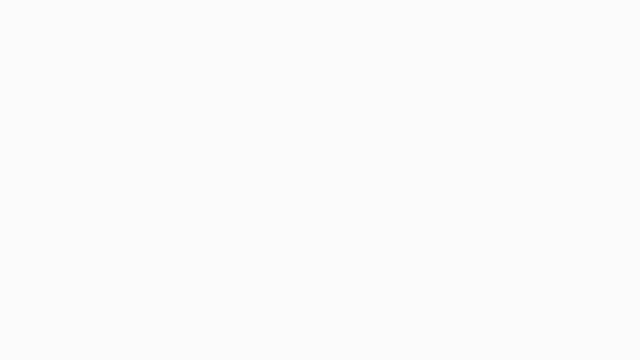

In [ ]:
from IPython.display import Image
Image(filename='../animations/gifs/lasso_l1_geometry.gif')

## Soft thresholding and coordinate descent

The way around the kink is to stop trying to move all coefficients at once. **Coordinate descent**
optimises one $\beta_j$ at a time with all the others held fixed. Along a single coordinate the
lasso objective is a one-dimensional problem that can be solved exactly, kink and all.

Write the residual with coordinate $j$ removed, $r^{(-j)} = y - \sum_{k \ne j} x_k\beta_k$, and let

$$\rho_j = x_j^\top r^{(-j)}, \qquad z_j = x_j^\top x_j$$

$\rho_j$ is the correlation between column $j$ and what the other coefficients have left unexplained
- the partial residual correlation. Minimising

$$\lVert r^{(-j)} - x_j\beta_j\rVert_2^2 + \lambda|\beta_j|$$

over the single scalar $\beta_j$ means setting the subgradient to zero:

$$-2\rho_j + 2z_j\beta_j + \lambda\,s = 0, \qquad
s \in \begin{cases} \{\operatorname{sign}(\beta_j)\} & \beta_j \ne 0 \\ [-1, 1] & \beta_j = 0\end{cases}$$

The interval at zero is what makes exact zeros possible: any $\rho_j$ with $|\rho_j| \le \lambda/2$
can be balanced by some $s$ in $[-1,1]$, so $\beta_j = 0$ genuinely solves the equation rather than
merely coming close. Solving gives

$$\beta_j \leftarrow \frac{S(\rho_j,\ \lambda/2)}{z_j}$$

where $S$ is the **soft-thresholding operator**

$$S(z, \gamma) = \operatorname{sign}(z)\,\max(|z| - \gamma,\ 0)$$

It subtracts $\gamma$ from the magnitude of $z$ and clamps at zero. Everything inside
$[-\gamma, \gamma]$ is mapped to exactly zero; everything outside is pulled toward zero by exactly
$\gamma$. The $\lambda/2$ rather than $\lambda$ is because the loss here is written as
$\lVert y - X\beta\rVert_2^2$ without a factor of $\tfrac12$ in front.

Cycling this update over $j = 1 \ldots d$ until nothing moves solves the whole problem. It converges
because the objective is convex and the non-differentiable part, $\lambda\sum_j|\beta_j|$, is
separable across coordinates - the kink in coordinate $j$ does not depend on any other coordinate,
so improving one at a time cannot get stuck.

The cell below defines `soft_threshold` and prints it over a range of inputs, so the flat dead zone
in the middle is visible directly.

In [10]:
def soft_threshold(z, gamma):
    return np.sign(z) * np.maximum(np.abs(z) - gamma, 0.0)


probe = np.array([-3.0, -2.0, -1.0, -0.5, -0.1, 0.0, 0.1, 0.5, 1.0, 2.0, 3.0])
print('S(z, gamma = 1.0)')
print('  z      ', ' '.join('%6.1f' % v for v in probe))
print('  S(z)   ', ' '.join('%6.1f' % v for v in soft_threshold(probe, 1.0)))
print()
print('everything with |z| <= 1.0 is mapped to exactly 0.0, not to something small')
print('values outside are pulled toward zero by exactly 1.0')

S(z, gamma = 1.0)
  z         -3.0   -2.0   -1.0   -0.5   -0.1    0.0    0.1    0.5    1.0    2.0    3.0
  S(z)      -2.0   -1.0   -0.0   -0.0   -0.0    0.0    0.0    0.0    0.0    1.0    2.0

everything with |z| <= 1.0 is mapped to exactly 0.0, not to something small
values outside are pulled toward zero by exactly 1.0


## Lasso

$$\hat\beta_{lasso} = \arg\min_\beta \ \lVert y - X\beta\rVert_2^2 + \lambda \lVert \beta \rVert_1$$

`Lasso_Regression.fit` runs the cycle described above. `col_sq` holds $z_j = x_j^\top x_j$ for every
column, computed once. `resid` holds the full residual $y - X\beta - \beta_0$ and is updated in
place: after changing $\beta_j$ from `old` to `new`, the residual only changes by
$(\text{new} - \text{old})\,x_j$. That keeps each coordinate update at the cost of two dot products
instead of a full matrix multiply.

The partial residual is recovered from the full one without recomputing it, using

$$\rho_j = x_j^\top r^{(-j)} = x_j^\top r + z_j\beta_j$$

which is the `rho` line.

The intercept is updated at the top of each sweep and is not penalised, so its optimal value with
everything else fixed is just the mean of the residual.

`beta_init` lets a fit start from an existing coefficient vector. That is used later to walk down a
path of $\lambda$ values, each fit starting from the previous solution, which cuts the number of
sweeps sharply.

The loop stops when the largest change in any coefficient during a sweep falls below `tol`, or after
`max_iter` sweeps. `self.history` records the objective after each sweep, and it must decrease
monotonically - each update is an exact minimisation along one coordinate, so it cannot make the
objective worse.

In [11]:
class Lasso_Regression:
    def __init__(self, lam=1.0, max_iter=500, tol=1e-6):
        self.lam = lam
        self.max_iter = max_iter
        self.tol = tol
        self.beta = None
        self.intercept = 0.0
        self.history = []
        self.sweeps = 0

    def fit(self, X, y, beta_init=None):
        n, d = X.shape
        col_sq = (X ** 2).sum(axis=0)

        beta = np.zeros(d) if beta_init is None else beta_init.copy()
        intercept = y.mean() - X.mean(axis=0) @ beta
        resid = y - X @ beta - intercept

        self.history = []
        for sweep in range(self.max_iter):
            # unpenalised intercept: its optimum is the residual mean
            shift = resid.mean()
            intercept += shift
            resid -= shift

            max_change = 0.0
            for j in range(d):
                old = beta[j]
                rho = X[:, j] @ resid + col_sq[j] * old
                new = soft_threshold(rho, self.lam / 2.0) / col_sq[j]
                if new != old:
                    resid -= (new - old) * X[:, j]
                    beta[j] = new
                    change = abs(new - old)
                    if change > max_change:
                        max_change = change

            self.history.append(np.sum(resid ** 2) + self.lam * np.abs(beta).sum())
            if max_change < self.tol:
                break

        self.beta = beta
        self.intercept = intercept
        self.sweeps = sweep + 1
        return self

    def predict(self, X):
        return X @ self.beta + self.intercept

Above a certain $\lambda$ every coefficient is zero. That happens as soon as the threshold exceeds
the largest partial residual correlation at $\beta = 0$, which is

$$\lambda_{\max} = 2\max_j |x_j^\top y|$$

Every path below starts there and works downward, so the whole useful range of $\lambda$ is covered
without guessing.

The cell fits one lasso at $\lambda_{\max}/50$ and reports how many coefficients survived and how
the objective moved.

In [12]:
lam_max = 2 * np.abs(X_train.T @ y_train).max()
print('lambda_max = %.4f  (every coefficient is zero at or above this)' % lam_max)
print()

lasso_demo = Lasso_Regression(lam=lam_max / 50.0).fit(X_train, y_train)

print('lasso at lambda = %.4f' % lasso_demo.lam)
print('  sweeps to converge:  %d' % lasso_demo.sweeps)
print('  objective first sweep %.4f -> last sweep %.4f' % (lasso_demo.history[0], lasso_demo.history[-1]))
print('  objective decreased monotonically:', bool(np.all(np.diff(lasso_demo.history) <= 1e-9)))
print()
print('  coefficients exactly zero: %d of %d' % (int((lasso_demo.beta == 0).sum()), len(lasso_demo.beta)))
print('  non-zero:                  %d' % int((lasso_demo.beta != 0).sum()))
print('  validation R2:             %.4f' % r_squared(y_val, lasso_demo.predict(X_val)))
print()
print('for comparison, ridge at lambda = 100 had %d exact zeros' % int((ridge_closed.beta == 0).sum()))

lambda_max = 410.0644  (every coefficient is zero at or above this)

lasso at lambda = 8.2013
  sweeps to converge:  110
  objective first sweep 29.8906 -> last sweep 24.5714
  objective decreased monotonically: True

  coefficients exactly zero: 71 of 100
  non-zero:                  29
  validation R2:             0.6957

for comparison, ridge at lambda = 100 had 0 exact zeros


## Elastic Net

Lasso has a weakness that follows directly from the corner argument: when several columns carry
nearly the same information, the diamond has no reason to prefer one corner over another, so lasso
picks one of them more or less arbitrarily and zeroes the rest. Small changes in the data can flip
which one it keeps. Ridge, by contrast, spreads the coefficient evenly over the group but keeps all
of them.

Elastic Net uses both penalties:

$$\arg\min_\beta \ \lVert y - X\beta\rVert_2^2
+ \lambda\left(\alpha\lVert\beta\rVert_1 + \tfrac{1}{2}(1-\alpha)\lVert\beta\rVert_2^2\right)$$

$\alpha = 1$ is exactly lasso, $\alpha = 0$ is ridge, and in between the constraint region is a
diamond with its edges bowed outward - still cornered, so still sparse, but rounded enough that
correlated columns are kept or dropped together.

The coordinate update comes from the same subgradient calculation with the extra quadratic term
included:

$$-2\rho_j + 2z_j\beta_j + \lambda\alpha\,s + \lambda(1-\alpha)\beta_j = 0$$

$$\beta_j \leftarrow \frac{S\!\left(\rho_j,\ \tfrac{1}{2}\lambda\alpha\right)}
{z_j + \tfrac{1}{2}\lambda(1-\alpha)}$$

The L1 part still appears as a soft threshold in the numerator, so exact zeros survive. The L2 part
appears as an addition to the denominator - a shrinkage factor that scales the whole coefficient
down. That denominator is also what stabilises the update when two columns are nearly identical:
$z_j$ alone can be close to degenerate across such a pair, and $\tfrac12\lambda(1-\alpha)$ keeps it
away from that.

`Elastic_Net.fit` is `Lasso_Regression.fit` with those two changes. Setting `alpha=1.0` reduces it
to the lasso update exactly, which the next cell checks.

In [13]:
class Elastic_Net:
    def __init__(self, lam=1.0, alpha=0.5, max_iter=500, tol=1e-6):
        self.lam = lam
        self.alpha = alpha
        self.max_iter = max_iter
        self.tol = tol
        self.beta = None
        self.intercept = 0.0
        self.history = []
        self.sweeps = 0

    def fit(self, X, y, beta_init=None):
        n, d = X.shape
        col_sq = (X ** 2).sum(axis=0)

        gamma = 0.5 * self.lam * self.alpha              # soft threshold on the L1 part
        shrink = 0.5 * self.lam * (1.0 - self.alpha)     # extra term in the denominator, from L2

        beta = np.zeros(d) if beta_init is None else beta_init.copy()
        intercept = y.mean() - X.mean(axis=0) @ beta
        resid = y - X @ beta - intercept

        self.history = []
        for sweep in range(self.max_iter):
            shift = resid.mean()
            intercept += shift
            resid -= shift

            max_change = 0.0
            for j in range(d):
                old = beta[j]
                rho = X[:, j] @ resid + col_sq[j] * old
                new = soft_threshold(rho, gamma) / (col_sq[j] + shrink)
                if new != old:
                    resid -= (new - old) * X[:, j]
                    beta[j] = new
                    change = abs(new - old)
                    if change > max_change:
                        max_change = change

            penalty = self.lam * (self.alpha * np.abs(beta).sum() + 0.5 * (1 - self.alpha) * np.sum(beta ** 2))
            self.history.append(np.sum(resid ** 2) + penalty)
            if max_change < self.tol:
                break

        self.beta = beta
        self.intercept = intercept
        self.sweeps = sweep + 1
        return self

    def predict(self, X):
        return X @ self.beta + self.intercept

In [14]:
check = Elastic_Net(lam=lam_max / 50.0, alpha=1.0).fit(X_train, y_train)
print('Elastic_Net at alpha = 1 vs Lasso_Regression, same lambda')
print('  largest absolute difference in beta: %.3e' % np.abs(check.beta - lasso_demo.beta).max())
print()

enet_demo = Elastic_Net(lam=lam_max / 50.0, alpha=0.5).fit(X_train, y_train)
print('Elastic_Net at alpha = 0.5, lambda = %.4f' % enet_demo.lam)
print('  sweeps:                    %d' % enet_demo.sweeps)
print('  non-zero coefficients:     %d of %d' % (int((enet_demo.beta != 0).sum()), len(enet_demo.beta)))
print('  lasso kept:                %d' % int((lasso_demo.beta != 0).sum()))
print('  validation R2:             %.4f' % r_squared(y_val, enet_demo.predict(X_val)))

Elastic_Net at alpha = 1 vs Lasso_Regression, same lambda
  largest absolute difference in beta: 0.000e+00



Elastic_Net at alpha = 0.5, lambda = 8.2013
  sweeps:                    167
  non-zero coefficients:     43 of 100
  lasso kept:                29
  validation R2:             0.6941


## Fitting the whole path

`ridge_path`, `lasso_path` and `enet_path` fit each model at every $\lambda$ on a logarithmic grid
and store the coefficient vector, along with train, validation and test errors.

The lasso and elastic net loops walk from large $\lambda$ down to small and pass the previous
solution in as `beta_init`. At large $\lambda$ almost everything is zero and the fit is trivial;
each step down only has to move a little, so the number of sweeps stays small. Starting each fit
from zero instead would be several times slower.

The grid runs from $\lambda_{\max}$ down to $\lambda_{\max}/1000$. Below that the fit approaches
unpenalised least squares, which is what the baseline already measures, and coordinate descent slows
down for the same ill-conditioning reason.

In [15]:
n_lam = 50

lasso_lambdas = np.logspace(np.log10(lam_max), np.log10(lam_max / 1000.0), n_lam)
ridge_lambdas = np.logspace(4, -2, n_lam)

def path_scores(beta, intercept):
    p_tr = X_train @ beta + intercept
    p_va = X_val @ beta + intercept
    p_te = X_test @ beta + intercept
    return (mse(y_train, p_tr), mse(y_val, p_va), mse(y_test, p_te),
            r_squared(y_val, p_va), r_squared(y_test, p_te))


ridge_coefs = np.zeros((n_lam, X_train.shape[1]))
ridge_stats = np.zeros((n_lam, 5))
for i, lam in enumerate(ridge_lambdas):
    m = Ridge_Regression(lam=lam).fit(X_train, y_train)
    ridge_coefs[i] = m.beta
    ridge_stats[i] = path_scores(m.beta, m.intercept)
print('ridge path done, %d fits' % n_lam)

lasso_coefs = np.zeros((n_lam, X_train.shape[1]))
lasso_stats = np.zeros((n_lam, 5))
warm = None
for i, lam in enumerate(lasso_lambdas):
    m = Lasso_Regression(lam=lam).fit(X_train, y_train, beta_init=warm)
    warm = m.beta
    lasso_coefs[i] = m.beta
    lasso_stats[i] = path_scores(m.beta, m.intercept)
    if i % 10 == 0 or i == n_lam - 1:
        print('  lasso %2d/%d  lambda %9.4f  non-zero %3d  sweeps %3d' %
              (i + 1, n_lam, lam, int((m.beta != 0).sum()), m.sweeps))

enet_coefs = np.zeros((n_lam, X_train.shape[1]))
enet_stats = np.zeros((n_lam, 5))
warm = None
for i, lam in enumerate(lasso_lambdas):
    m = Elastic_Net(lam=lam, alpha=0.5).fit(X_train, y_train, beta_init=warm)
    warm = m.beta
    enet_coefs[i] = m.beta
    enet_stats[i] = path_scores(m.beta, m.intercept)
    if i % 10 == 0 or i == n_lam - 1:
        print('  enet  %2d/%d  lambda %9.4f  non-zero %3d  sweeps %3d' %
              (i + 1, n_lam, lam, int((m.beta != 0).sum()), m.sweeps))

ridge_nonzero = (np.abs(ridge_coefs) > 1e-12).sum(axis=1)
lasso_nonzero = (lasso_coefs != 0).sum(axis=1)
enet_nonzero = (enet_coefs != 0).sum(axis=1)
print()
print('non-zero coefficients at the smallest lambda: ridge %d, lasso %d, elastic net %d' %
      (ridge_nonzero[-1], lasso_nonzero[-1], enet_nonzero[-1]))

ridge path done, 50 fits
  lasso  1/50  lambda  410.0644  non-zero   1  sweeps   1


  lasso 11/50  lambda  100.1399  non-zero   4  sweeps  15


  lasso 21/50  lambda   24.4547  non-zero  11  sweeps  61


  lasso 31/50  lambda    5.9720  non-zero  37  sweeps  78


  lasso 41/50  lambda    1.4584  non-zero  69  sweeps 254


...

  enet  11/50  lambda  100.1399  non-zero   8  sweeps  52


  enet  21/50  lambda   24.4547  non-zero  20  sweeps  53


  enet  31/50  lambda    5.9720  non-zero  53  sweeps 141


  enet  41/50  lambda    1.4584  non-zero  80  sweeps 354


  enet  50/50  lambda    0.4101  non-zero  95  sweeps 500

non-zero coefficients at the smallest lambda: ridge 100, lasso 89, elastic net 95


## Coefficient paths

The signature chart. Each thin line is one of the 100 coefficients plotted against $\log_{10}\lambda$,
ridge on the left and lasso on the right. Both panels are read right to left: heavy penalty on the
right, light penalty on the left.

`highlight` picks the five features with the largest lasso coefficients at the smallest $\lambda$ and
draws them in colour in both panels, so the same feature can be followed across the two.

Ridge coefficients fan out smoothly and together - every one of them is non-zero at every $\lambda$,
just uniformly smaller as $\lambda$ grows. Lasso coefficients hit zero and stay there, one at a time,
so the right-hand panel collapses onto the axis as $\lambda$ increases.

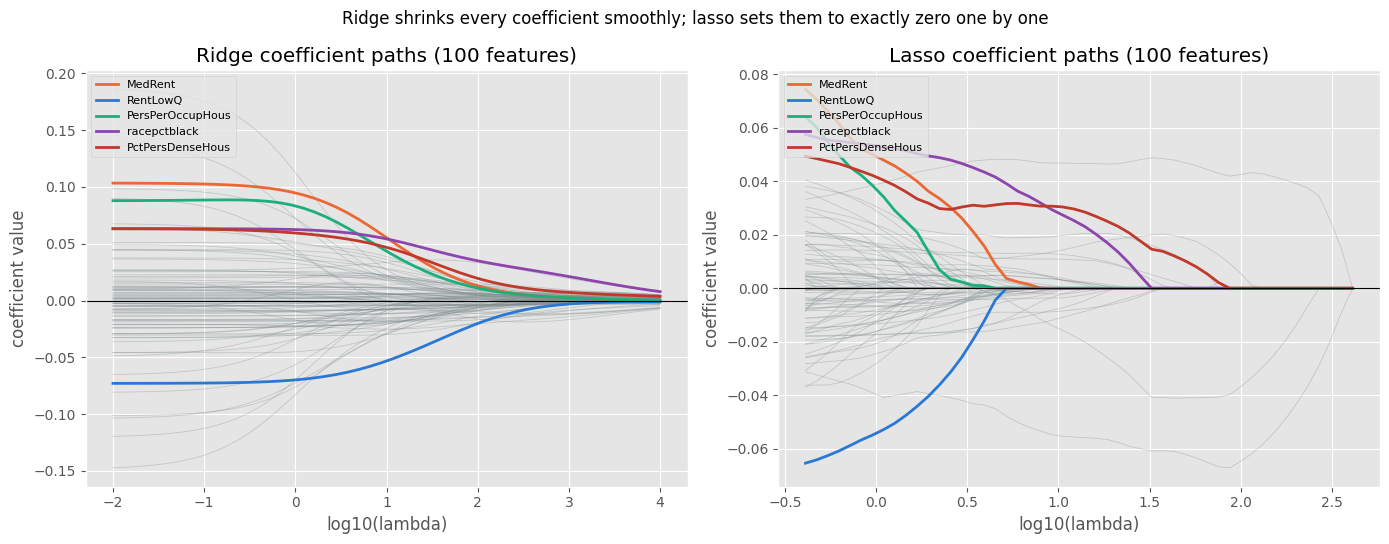

In [16]:
final_lasso = lasso_coefs[-1]
highlight = np.argsort(np.abs(final_lasso))[-5:][::-1]
colours = [orange, blue, aqua, '#8e44ad', '#c0392b']

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for ax, coefs, lams, name in [(axes[0], ridge_coefs, ridge_lambdas, 'Ridge'),
                              (axes[1], lasso_coefs, lasso_lambdas, 'Lasso')]:
    logl = np.log10(lams)
    for j in range(coefs.shape[1]):
        ax.plot(logl, coefs[:, j], color='#7f8c8d', linewidth=0.6, alpha=0.35)
    for k, j in enumerate(highlight):
        ax.plot(logl, coefs[:, j], color=colours[k], linewidth=2.0, label=feature_names[j])
    ax.axhline(0.0, color='k', linewidth=0.8)
    ax.set_xlabel('log10(lambda)')
    ax.set_ylabel('coefficient value')
    ax.set_title('%s coefficient paths (%d features)' % (name, coefs.shape[1]))
    ax.legend(fontsize=8, loc='upper left')

fig.suptitle('Ridge shrinks every coefficient smoothly; lasso sets them to exactly zero one by one')
fig.tight_layout()
plt.show()

## How many coefficients survive

The same story counted rather than drawn. The y axis is the number of coefficients not equal to
zero, against $\log_{10}\lambda$.

Ridge is a flat line at 100 - the closed form divides by $\lambda_k + \lambda$, which is never
infinite, so no coefficient is ever exactly zero no matter how hard it is penalised. Lasso and
elastic net fall from 100 to 0 across the grid. Elastic net sits above lasso at the same $\lambda$
because only the fraction $\alpha$ of the penalty is doing the thresholding.

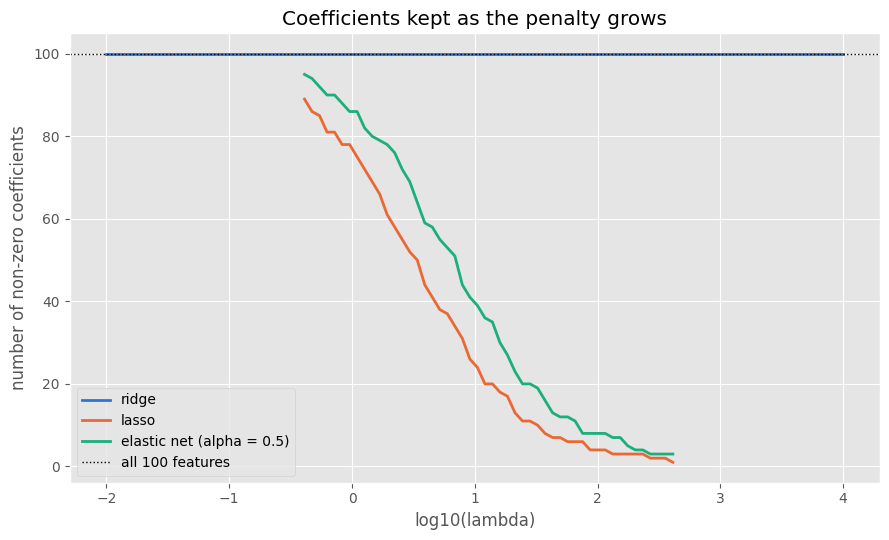

In [17]:
plt.figure(figsize=(9, 5.5))
plt.plot(np.log10(ridge_lambdas), ridge_nonzero, color=blue, linewidth=2, label='ridge')
plt.plot(np.log10(lasso_lambdas), lasso_nonzero, color=orange, linewidth=2, label='lasso')
plt.plot(np.log10(lasso_lambdas), enet_nonzero, color=aqua, linewidth=2, label='elastic net (alpha = 0.5)')
plt.axhline(X_train.shape[1], color='k', linestyle=':', linewidth=1, label='all %d features' % X_train.shape[1])
plt.xlabel('log10(lambda)')
plt.ylabel('number of non-zero coefficients')
plt.title('Coefficients kept as the penalty grows')
plt.legend()
plt.tight_layout()
plt.show()

## Choosing lambda

One panel per method. Each shows mean squared error against $\log_{10}\lambda$ on the training set,
the validation set and the test set, with a vertical line at the $\lambda$ that minimises validation
error and a horizontal line at the OLS validation error for reference.

The shape to look for is the training curve rising steadily with $\lambda$ while the validation curve
falls first and only then rises. The gap between them on the left is variance; the rise on the right
is bias. `best_idx` is where the second effect starts to outweigh the first.

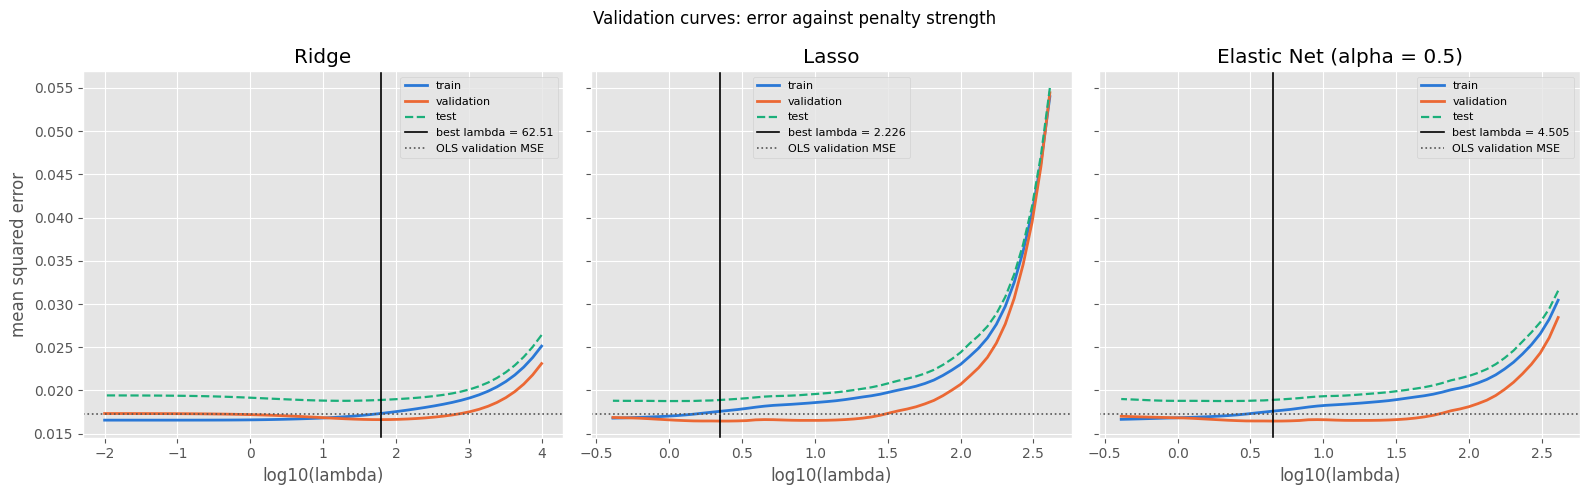

best lambda by validation error
  ridge          62.5055   validation MSE 0.016623
  lasso           2.2261   validation MSE 0.016456
  elastic net     4.5047   validation MSE 0.016456
  OLS                        validation MSE 0.017331


In [18]:
best_ridge_i = int(np.argmin(ridge_stats[:, 1]))
best_lasso_i = int(np.argmin(lasso_stats[:, 1]))
best_enet_i = int(np.argmin(enet_stats[:, 1]))

ols_val_mse = mse(y_val, pred_val_ols)

panels = [('Ridge', ridge_lambdas, ridge_stats, best_ridge_i),
          ('Lasso', lasso_lambdas, lasso_stats, best_lasso_i),
          ('Elastic Net (alpha = 0.5)', lasso_lambdas, enet_stats, best_enet_i)]

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
for ax, (name, lams, stats, bi) in zip(axes, panels):
    logl = np.log10(lams)
    ax.plot(logl, stats[:, 0], color=blue, linewidth=2, label='train')
    ax.plot(logl, stats[:, 1], color=orange, linewidth=2, label='validation')
    ax.plot(logl, stats[:, 2], color=aqua, linewidth=1.6, linestyle='--', label='test')
    ax.axvline(logl[bi], color='k', linewidth=1.2, linestyle='-', label='best lambda = %.4g' % lams[bi])
    ax.axhline(ols_val_mse, color='#555555', linewidth=1.2, linestyle=':', label='OLS validation MSE')
    ax.set_xlabel('log10(lambda)')
    ax.set_title(name)
    ax.legend(fontsize=8)
axes[0].set_ylabel('mean squared error')
fig.suptitle('Validation curves: error against penalty strength')
fig.tight_layout()
plt.show()

print('best lambda by validation error')
print('  ridge       %10.4f   validation MSE %.6f' % (ridge_lambdas[best_ridge_i], ridge_stats[best_ridge_i, 1]))
print('  lasso       %10.4f   validation MSE %.6f' % (lasso_lambdas[best_lasso_i], lasso_stats[best_lasso_i, 1]))
print('  elastic net %10.4f   validation MSE %.6f' % (lasso_lambdas[best_enet_i], enet_stats[best_enet_i, 1]))
print('  OLS                        validation MSE %.6f' % ols_val_mse)

## Test scores

The $\lambda$ values are now fixed by the validation set, so the test set can be used once. The cell
collects the four models and prints train, validation and test $R^2$ together with how many
coefficients each one kept.

In [19]:
# refit at the chosen lambda so the intercept comes back with the coefficients
ridge_best = Ridge_Regression(lam=ridge_lambdas[best_ridge_i]).fit(X_train, y_train)
lasso_best = Lasso_Regression(lam=lasso_lambdas[best_lasso_i]).fit(X_train, y_train)
enet_best = Elastic_Net(lam=lasso_lambdas[best_enet_i], alpha=0.5).fit(X_train, y_train)

models = [('OLS', beta_ols, intercept_ols, float('nan')),
          ('Ridge', ridge_best.beta, ridge_best.intercept, ridge_best.lam),
          ('Lasso', lasso_best.beta, lasso_best.intercept, lasso_best.lam),
          ('Elastic Net', enet_best.beta, enet_best.intercept, enet_best.lam)]

names = []
test_r2 = []
print('%-12s %10s %8s %8s %8s %10s' % ('model', 'lambda', 'trainR2', 'valR2', 'testR2', 'non-zero'))
for name, b, b0, lam in models:
    tr = r_squared(y_train, X_train @ b + b0)
    va = r_squared(y_val, X_val @ b + b0)
    te = r_squared(y_test, X_test @ b + b0)
    nz = int((b != 0).sum())
    names.append(name)
    test_r2.append(te)
    print('%-12s %10.4f %8.4f %8.4f %8.4f %10d' % (name, lam, tr, va, te, nz))

print()
print('lasso set %d of %d coefficients to exactly zero' % (int((lasso_best.beta == 0).sum()), len(lasso_best.beta)))
print('elastic net set %d of %d to exactly zero' % (int((enet_best.beta == 0).sum()), len(enet_best.beta)))
print('ridge set %d to exactly zero' % int((ridge_best.beta == 0).sum()))
print()
print('largest |beta|:  OLS %.4f   ridge %.4f   lasso %.4f   elastic net %.4f' %
      (np.abs(beta_ols).max(), np.abs(ridge_best.beta).max(),
       np.abs(lasso_best.beta).max(), np.abs(enet_best.beta).max()))

model            lambda  trainR2    valR2   testR2   non-zero
OLS                 nan   0.6932   0.6811   0.6467        100
Ridge           62.5055   0.6789   0.6941   0.6563        100
Lasso            2.2261   0.6743   0.6972   0.6563         58
Elastic Net      4.5047   0.6740   0.6972   0.6561         58

lasso set 42 of 100 coefficients to exactly zero
elastic net set 42 of 100 to exactly zero
ridge set 0 to exactly zero

largest |beta|:  OLS 0.1872   ridge 0.0385   lasso 0.0488   elastic net 0.0487


Test $R^2$ for the four models side by side, each at the $\lambda$ chosen on the validation set. The
bar labels carry the exact values.

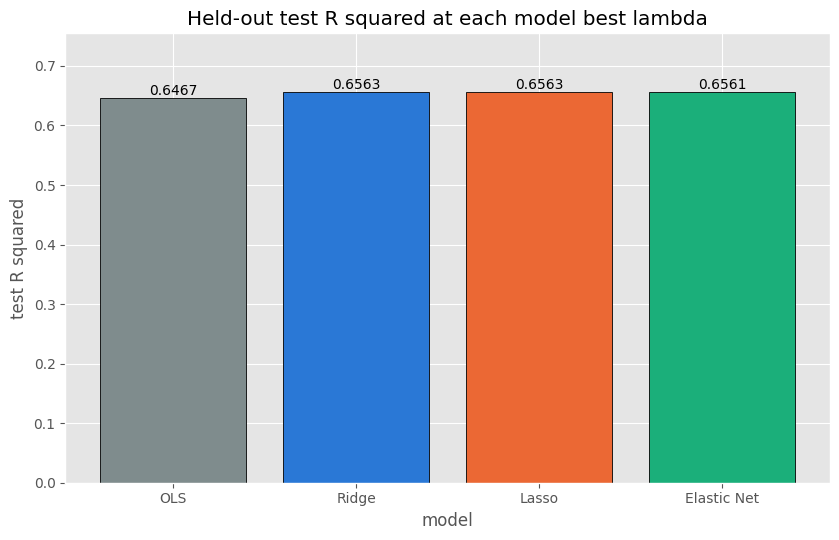

In [20]:
plt.figure(figsize=(8.5, 5.5))
bar_colours = ['#7f8c8d', blue, orange, aqua]
bars = plt.bar(names, test_r2, color=bar_colours, edgecolor='k', linewidth=0.6)
for b, v in zip(bars, test_r2):
    plt.text(b.get_x() + b.get_width() / 2, v + 0.005, '%.4f' % v, ha='center', fontsize=10)
plt.ylabel('test R squared')
plt.xlabel('model')
plt.title('Held-out test R squared at each model best lambda')
plt.ylim(0, max(test_r2) * 1.15)
plt.tight_layout()
plt.show()

## Where the penalty actually matters

The gap between OLS and the penalised fits on the full training set is not large, and the reason is
that 1195 training rows for 100 features is not a hard problem - there is enough data to pin the
coefficients down even along the poorly determined directions. The penalty has little left to
contribute.

Shrinking the training set changes that, and it changes it in the way the theory predicts. The cell
repeats the whole comparison on nested subsamples of the training rows, from 80 rows (fewer rows
than features, so $X^\top X$ is singular outright and `pinv` returns the minimum-norm solution) up to
the full set. $\lambda$ is chosen on the same validation set each time and the score is on the same
test set, so the columns are comparable down the table.

This is the bias-variance trade-off as a table: the fewer rows, the more variance there is to cut,
and the more the penalty is worth.

In [21]:
sizes = [80, 150, 300, 600, len(train_idx)]
rng_sub = np.random.RandomState(7)

print('test R2 by training set size, lambda chosen on the validation set')
print('%9s %10s %10s %10s %12s' % ('n train', 'OLS', 'ridge', 'lasso', 'lasso kept'))
for m_rows in sizes:
    idx = train_idx[rng_sub.permutation(len(train_idx))[:m_rows]]

    mu_s = X_all[idx].mean(axis=0)
    sd_s = X_all[idx].std(axis=0)
    sd_s[sd_s == 0] = 1.0
    Xs = (X_all[idx] - mu_s) / sd_s
    Xv = (X_all[val_idx] - mu_s) / sd_s
    Xt = (X_all[test_idx] - mu_s) / sd_s

    ms = y_all[idx].mean()
    ys = y_all[idx] - ms
    yv = y_all[val_idx] - ms
    yt = y_all[test_idx] - ms

    b, b0 = fit_ols(Xs, ys)
    ols_te = r_squared(yt, Xt @ b + b0)

    best = None
    for lam in np.logspace(4, -2, 25):
        m = Ridge_Regression(lam=lam).fit(Xs, ys)
        v = r_squared(yv, m.predict(Xv))
        if best is None or v > best[0]:
            best = (v, r_squared(yt, m.predict(Xt)))
    ridge_te = best[1]

    lm = 2 * np.abs(Xs.T @ ys).max()
    warm = None
    best = None
    for lam in np.logspace(np.log10(lm), np.log10(lm / 1000.0), 25):
        m = Lasso_Regression(lam=lam).fit(Xs, ys, beta_init=warm)
        warm = m.beta
        v = r_squared(yv, m.predict(Xv))
        if best is None or v > best[0]:
            best = (v, r_squared(yt, m.predict(Xt)), int((m.beta != 0).sum()))

    print('%9d %10.4f %10.4f %10.4f %12d' % (m_rows, ols_te, ridge_te, best[1], best[2]))

test R2 by training set size, lambda chosen on the validation set
  n train        OLS      ridge      lasso   lasso kept


       80    -1.0855     0.5942     0.5903           14


      150    -0.5414     0.6181     0.6114           14


      300     0.4873     0.6001     0.6052           23


      600     0.6064     0.6472     0.6481           49


     1195     0.6467     0.6566     0.6560           57


## What lasso kept

The payoff of exact zeros: instead of 100 coefficients to interpret there is a short list. The chart
shows the surviving lasso coefficients with the largest magnitude, labelled by column name, with the
sign shown by colour. Positive coefficients push the predicted violent crime rate up, negative ones
pull it down, and both are per one standard deviation of the feature because the columns were
standardised.

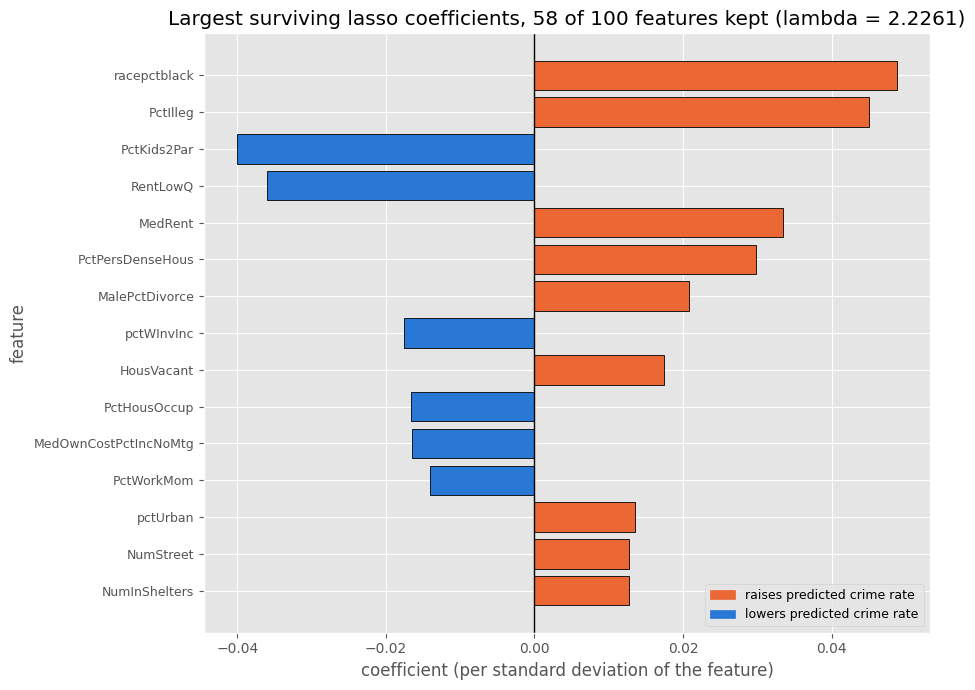

In [22]:
nz_idx = np.where(lasso_best.beta != 0)[0]
top = nz_idx[np.argsort(np.abs(lasso_best.beta[nz_idx]))[-15:]]
vals = lasso_best.beta[top]
labels = [feature_names[j] for j in top]

plt.figure(figsize=(9.5, 7))
cols = [orange if v > 0 else blue for v in vals]
plt.barh(range(len(top)), vals, color=cols, edgecolor='k', linewidth=0.6)
plt.yticks(range(len(top)), labels, fontsize=9)
plt.axvline(0, color='k', linewidth=1)
plt.xlabel('coefficient (per standard deviation of the feature)')
plt.ylabel('feature')
plt.title('Largest surviving lasso coefficients, %d of %d features kept (lambda = %.4f)'
          % (len(nz_idx), len(lasso_best.beta), lasso_best.lam))
handles = [plt.Rectangle((0, 0), 1, 1, color=orange), plt.Rectangle((0, 0), 1, 1, color=blue)]
plt.legend(handles, ['raises predicted crime rate', 'lowers predicted crime rate'], fontsize=9, loc='lower right')
plt.tight_layout()
plt.show()

## Predicted against actual

The best model by test $R^2$, plotted prediction against truth on the test rows with the line
$y = x$. Points on the line are exact; the vertical spread around it is the error. The values are on
the centred scale, so zero is the training mean of the crime rate.

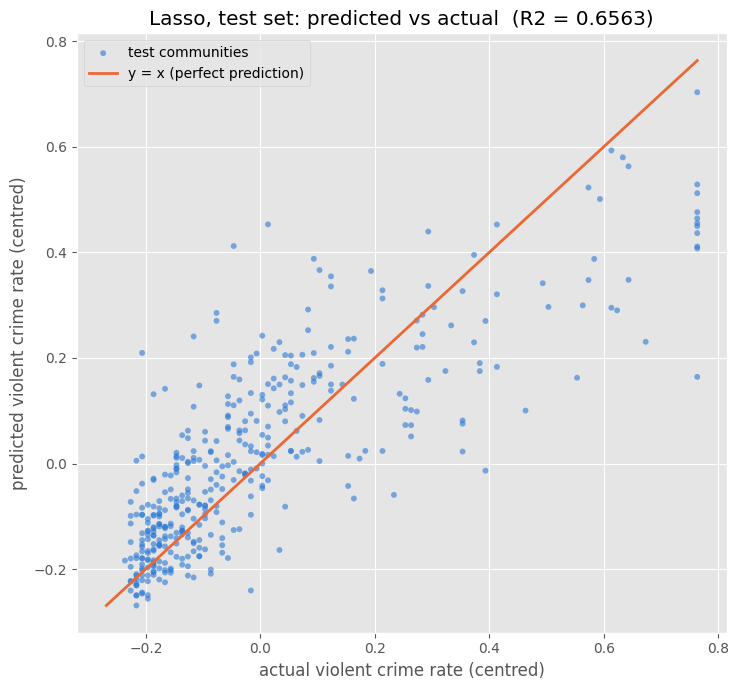

best model on the test set: Lasso
test R2  0.6563
test MSE 0.018897
residual standard deviation 0.1363, against a target standard deviation of 0.2345


In [23]:
best_i = int(np.argmax(test_r2))
best_name, best_beta, best_b0, best_lam = models[best_i]
pred = X_test @ best_beta + best_b0

lo = min(y_test.min(), pred.min())
hi = max(y_test.max(), pred.max())

plt.figure(figsize=(7.5, 7))
plt.scatter(y_test, pred, s=18, color=blue, alpha=0.6, edgecolors='none', label='test communities')
plt.plot([lo, hi], [lo, hi], color=orange, linewidth=2, label='y = x (perfect prediction)')
plt.xlabel('actual violent crime rate (centred)')
plt.ylabel('predicted violent crime rate (centred)')
plt.title('%s, test set: predicted vs actual  (R2 = %.4f)' % (best_name, test_r2[best_i]))
plt.legend()
plt.tight_layout()
plt.show()

print('best model on the test set: %s' % best_name)
print('test R2  %.4f' % test_r2[best_i])
print('test MSE %.6f' % mse(y_test, pred))
print('residual standard deviation %.4f, against a target standard deviation of %.4f'
      % ((y_test - pred).std(), y_test.std()))

## The bias-variance trade-off

OLS is unbiased: run it on many samples from the same population and the average of the fitted
coefficients is the truth. That sounds like the property to want, and on its own it is not worth
much, because unbiasedness says nothing about how far any single fit lands from the truth. The
variance of $\hat\beta_{OLS}$ is $\sigma^2 (X^\top X)^{-1}$, whose eigenvalues are the reciprocals
of the ones printed near the top. The smallest eigenvalue of $X^\top X$ therefore sets the largest
variance, and that direction is where an unpenalised fit is free to put coefficients that the data
does not really support.

Expected squared prediction error decomposes as

$$\mathbb{E}\left[(y - \hat f(x))^2\right] = \text{bias}^2 + \text{variance} + \sigma^2$$

Only the first two are under any control. All three penalties buy a reduction in the second by
paying for it in the first: shrinking coefficients toward zero biases them, and the bias grows with
$\lambda$, but the variance falls faster at first. $\lambda$ is the dial, and the validation curves
above are that trade-off drawn out - the training error, which sees no variance because it is
measured on the rows that were fitted, rises monotonically with $\lambda$, while the validation
error dips before it climbs.

At $\lambda \to 0$ every method returns to OLS, all variance and no bias. At $\lambda \to \infty$
every coefficient goes to zero and the model predicts the mean for everything, all bias and no
variance. The useful models are in between.

## Summary

- The dataset arrives with 127 columns and 1994 rows. Five identifier columns are dropped, 22
  columns from the LEMAS police survey are dropped because 84% of their values are missing, and one
  row is dropped for a single remaining missing value, leaving **100 features and 1993 rows**.
- The condition number of $X^\top X$ on the standardised training features is printed above, and it
  is large enough that the unpenalised inverse is not meaningful. Adding $\lambda I$ shifts every
  eigenvalue up by $\lambda$ and brings the condition number down by orders of magnitude.
- **Ridge** solves in closed form, $(X^\top X + \lambda I)^{-1}X^\top y$, with the intercept left
  unpenalised. Gradient descent on the same objective, with a step size set by the largest Hessian
  eigenvalue, reaches the same coefficients.
- **Lasso** has no closed form because $|\beta_j|$ is not differentiable at zero. Coordinate descent
  handles it by solving one coordinate at a time, where the subgradient condition at zero has slack,
  and that is exactly what the soft-thresholding operator implements.
- **Elastic Net** keeps the soft threshold in the numerator, so it still zeroes coefficients, and
  adds the L2 term to the denominator, so correlated columns are treated as a group.
- Ridge left every coefficient non-zero at every $\lambda$. Lasso and elastic net cut the model to a
  short list of features, and the surviving coefficients are directly readable.
- The scores are printed above rather than asserted here. The point of the comparison is not that
  penalisation always wins on a single held-out split - it is that it costs nothing in accuracy on
  this data while producing coefficients that are bounded, stable and, for lasso, few.